# 00 · Data cleanup

The Boltzina v1.0.1 release ships one CSV per MF-PCBA target with compound SMILES, binary activity, and cached Boltz-2 scores. The BoltzFT pipeline expects a specific schema (`CID`, `neut-smiles`, `Active_v2`, `affinity_probability_binary`). This notebook documents the exact, reproducible transformation from the **distributed** columns to that schema, and validates that no compounds are silently lost.

In [1]:
import os, gzip, warnings
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_columns", 40)

ROOT = Path("/global/scratch/users/sergiomar10/boltzaff")
RAW  = ROOT / "data" / "mf-pcba_test"       # distributed per-target CSVs
DATA = ROOT / "data"                        # our cleaned CSVs + seqs + MSAs
SPLITS = ROOT / "BoltzFT" / "data" / "splits"

# target folder -> (protein, source structure/GI)
TARGETS = {
 "588689":         ("Dengue-2 NS5 MTase",      "PDB 3EVG"),
 "540297-493091":  ("SCP1 phosphatase",        "PDB 3PGL"),
 "434954-2097":    ("GSK-3\u03b2",               "PDB 1J1B"),
 "463203-2650":    ("GSK-3\u03b1",               "PDB 7SXF"),
 "493248-485317":  ("ALR / GFER oxidase",      "PDB 3MBG"),
 "504329":         ("Influenza A NS1",         "predicted (GI 227977143)"),
 "624273-588549":  ("M.tb FadD28 ligase",      "predicted (GI 1781172)"),
 "1053173-743445": ("NSD2 PWWP1 domain",       "PDB 6UE6"),
}

# Paper Table 1 (Furui & Ohue, arXiv:2609.24302), for validation.
# target -> dict(neval, nactive_eval, active_rate_pct, train_actives {40,100,300})
PAPER_T1 = {
 "588689":        dict(neval=49685, nact=396, rate=0.80, tr={40:16,100:32,300:90}),
 "540297-493091": dict(neval=49685, nact=739, rate=1.49, tr={40:8, 100:16,300:43}),
 "434954-2097":   dict(neval=49615, nact=415, rate=0.84, tr={40:24,100:52,300:107}),
 "463203-2650":   dict(neval=49582, nact=542, rate=1.09, tr={40:13,100:29,300:70}),
 "493248-485317": dict(neval=49680, nact=953, rate=1.92, tr={40:1, 100:9, 300:23}),
 "504329":        dict(neval=49682, nact=438, rate=0.88, tr={40:4, 100:11,300:28}),
 "624273-588549": dict(neval=49687, nact=150, rate=0.30, tr={40:4, 100:4, 300:9}),
 "1053173-743445":dict(neval=49695, nact=134, rate=0.27, tr={40:0, 100:5, 300:10}),
}

def load_split_order(t):
    """Return the score_boltz2-descending CID ranking shipped in data/splits."""
    p = SPLITS / f"{t}.txt.gz"
    with gzip.open(p, "rt") as f:
        return [int(x.strip().removeprefix(t + "_")) for x in f]


In [2]:
import matplotlib as mpl, matplotlib.pyplot as plt
PALETTE = ["#2a78d6","#eb6834","#1baf7a","#eda100","#e87ba4","#008300","#4a3aa7","#e34948"]
INK, MUTED, SURF = "#0b0b0b", "#52514e", "#fcfcfb"
ACTIVE, INACTIVE, BLUE = "#e34948", "#b8b6ad", "#2a78d6"
TCOLOR = {t: PALETTE[i] for i, t in enumerate(TARGETS)}   # fixed hue per target
mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 100})


## Raw distributed schema
Columns as shipped for target 588689.

In [3]:
t = "588689"
raw = pd.read_csv(RAW / f"{t}.csv")
print("shape:", raw.shape)
print("columns:", list(raw.columns))
raw.head(3)

shape: (49985, 18)
columns: ['CID', 'target_active_v2', 'SD', 'SD Z-score', 'DR', 'Activity', 'neut-smiles', '# stereocenters', 'PAINS', 'score_boltz2', 'score_boltzina', 'docking_score_boltzina', 'score_boltzina_recycle1', 'docking_score_boltzina_recycle1', 'score_boltzina_mask', 'docking_score_boltzina_mask', 'score_gnina', 'score_vina']


,CID,target_active_v2,SD,SD Z-score,DR,Activity,neut-smiles,# stereocenters,PAINS,score_boltz2,score_boltzina,docking_score_boltzina,score_boltzina_recycle1,docking_score_boltzina_recycle1,score_boltzina_mask,docking_score_boltzina_mask,score_gnina,score_vina
0,3157647,True,110.91,11.244159,4.553774,Active,COCCNC(=O)Nc1ccc2nc(-c3ccco3)c(-c3ccco3)nc2c1,0,False,0.612798,0.630809,-7.995,0.599590,-7.995,0.596470,-7.995,NaN,NaN
1,216328,True,102.64,10.419098,4.418619,Active,COc1cc(O)cc2cc3c(c(O)c12)C(=O)CC(C)(O)O3,1,False,0.436412,0.657888,-7.512,0.646726,-7.512,0.680746,-7.512,NaN,NaN
2,1130377,True,102.03,10.358241,5.022734,Active,CC1(C)CC(=O)C(C(C2=C(O)CC(C)(C)CC2=O)c2ccc(O)c...,0,False,0.553958,0.527234,-7.929,0.487225,-7.929,0.446733,-7.929,NaN,NaN


## The cleanup mapping
- `target_active_v2` (bool) &rarr; **`Active_v2`** (int 0/1)
- `score_boltz2` (standard Boltz-2 binding probability) &rarr; **`affinity_probability_binary`**
- drop rows with missing score or SMILES; drop duplicate CIDs (keep first)
- reindex to the shipped `data/splits/<target>.txt.gz` ranking (Boltz-2 score descending)

We confirmed the split file order **is** `score_boltz2` descending, so the ranking used to pick the top-N training compounds is exactly the standard Boltz-2 ranking.

In [4]:
def clean(t):
    raw = pd.read_csv(RAW / f"{t}.csv")
    out = pd.DataFrame({
        "CID": raw["CID"].astype(int),
        "neut-smiles": raw["neut-smiles"],
        "Active_v2": raw["target_active_v2"].astype(bool).astype(int),
        "affinity_probability_binary": raw["score_boltz2"],
    })
    n0 = len(out)
    out = out.dropna(subset=["affinity_probability_binary", "neut-smiles"]).drop_duplicates("CID", keep="first")
    order = load_split_order(t)
    missing = set(order) - set(out.CID)
    out = out.set_index("CID").loc[order].reset_index()
    return out, dict(raw_rows=n0, after_clean=len(out), dropped=n0-len(out),
                     split_ids=len(order), missing_from_clean=len(missing))

out, info = clean("588689")
print(info)
out.head(3)

{'raw_rows': 49985, 'after_clean': 49985, 'dropped': 0, 'split_ids': 49985, 'missing_from_clean': 0}


,CID,neut-smiles,Active_v2,affinity_probability_binary
0,5342569,O=C(O)C=CC(=O)Nc1ccc(C2(c3ccc(NC(=O)C=CC(=O)O)...,1,0.778554
1,3117,CCN(CC)C(=S)SSC(=S)N(CC)CC,0,0.767335
2,973894,COc1ccccc1-n1c(-c2ccco2)n[nH]c1=S,0,0.763108


## Verify the shipped `*_results.csv` matches this transform
The pipeline consumes `data/<target>_results.csv`, produced by exactly this mapping.

In [5]:
# Align on CID (the shipped CSV is in raw order; clean() reindexes to the split ranking,
# but select_subsets/build_ft_inputs reindex by the split anyway, so order is cosmetic).
s = pd.read_csv(DATA / "588689_results.csv").set_index("CID").sort_index()
r = clean("588689")[0].set_index("CID").sort_index()
assert s.index.equals(r.index), "CID sets differ"
assert np.allclose(s["affinity_probability_binary"], r["affinity_probability_binary"])
assert (s["Active_v2"] == r["Active_v2"]).all()
print(f"shipped 588689_results.csv reproduces the cleanup exactly \u2713  ({len(s)} compounds, CID-aligned)")

shipped 588689_results.csv reproduces the cleanup exactly ✓  (49985 compounds, CID-aligned)


## Cleanup summary across all 8 targets
No compounds are dropped and every split ID resolves.

In [6]:
rows = []
for t in TARGETS:
    _, info = clean(t)
    rows.append({"target": t, "protein": TARGETS[t][0], **info})
summary = pd.DataFrame(rows)
summary

,target,protein,raw_rows,after_clean,dropped,split_ids,missing_from_clean
0,588689,Dengue-2 NS5 MTase,49985,49985,0,49985,0
1,540297-493091,SCP1 phosphatase,49985,49985,0,49985,0
2,434954-2097,GSK-3β,49915,49915,0,49915,0
3,463203-2650,GSK-3α,49882,49882,0,49882,0
4,493248-485317,ALR / GFER oxidase,49980,49980,0,49980,0
5,504329,Influenza A NS1,49982,49982,0,49982,0
6,624273-588549,M.tb FadD28 ligase,49987,49987,0,49987,0
7,1053173-743445,NSD2 PWWP1 domain,49995,49995,0,49995,0


## Column completeness in the raw data
Fraction of non-missing values per raw column (588689). Boltz-2 / Boltzina scores are complete; some comparator columns (e.g. GNINA/Vina) are sparse or absent \u2014 which is why the pipeline keys on `score_boltz2` and the binary label rather than the docking comparators.

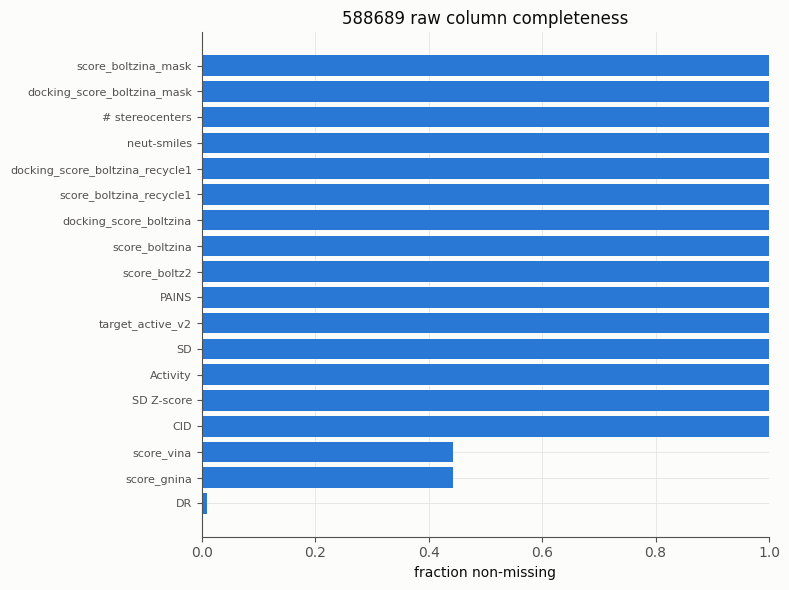

In [7]:
import matplotlib as mpl, matplotlib.pyplot as plt
PALETTE = ["#2a78d6","#eb6834","#1baf7a","#eda100","#e87ba4","#008300","#4a3aa7","#e34948"]
INK, MUTED, SURF = "#0b0b0b", "#52514e", "#fcfcfb"
ACTIVE, INACTIVE, BLUE = "#e34948", "#b8b6ad", "#2a78d6"
TCOLOR = {t: PALETTE[i] for i, t in enumerate(TARGETS)}   # fixed hue per target
mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 100})

raw = pd.read_csv(RAW / "588689.csv")
frac = raw.notna().mean().sort_values()
fig,ax=plt.subplots(figsize=(8,6))
ax.barh(range(len(frac)), frac.values, color=BLUE)
ax.set_yticks(range(len(frac))); ax.set_yticklabels(frac.index, fontsize=8)
ax.set_xlim(0,1); ax.set_xlabel("fraction non-missing"); ax.set_title("588689 raw column completeness")
plt.tight_layout(); plt.show()